#### Projeto Integrador III – Sprint 04: Base de Dados Sintética de Estudantes Universitários
###### **Alunos**: Maria Eduarda da Cruz | Yghor Kristian Andrade | **Orientador:** Rômulo Francisco de Souza

##### 01. Configuração do Notebook

In [1]:
import pandas as pd
import hashlib
import random
import uuid
import os
import time
from datetime import datetime, timedelta

import sys
!{sys.executable} -m pip install faker pysentimiento --quiet

from faker import Faker
from pysentimiento import create_analyzer
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fake = Faker("pt_BR")
random.seed(42)

INICIO = datetime(2023, 1, 1)
FIM    = datetime(2025, 12, 31)

def hash_senha(s): return hashlib.sha256(s.encode()).hexdigest()
def data_aleatoria(i, f):
    delta = f - i
    return i + timedelta(seconds=random.randint(0, int(delta.total_seconds())))

print("Setup concluído!")


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\Fenec\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup concluído!


##### 02. Perfis de Usuários da Base

In [8]:
UNIVERSIDADES = {
    "USP":      {"nome": "Universidade de São Paulo",               "tipo": "pública",  "regiao": "SP", "municipio": "São Paulo",       "perfil": "progressista-técnico",    "girias": ["mano", "cara", "véi", "tá ligado", "daora"],                          "cursos": ["Direito", "Medicina", "Engenharia", "Ciências Sociais", "Ciência da Computação"]},
    "UNICAMP":  {"nome": "Universidade Estadual de Campinas",        "tipo": "pública",  "regiao": "SP", "municipio": "Campinas",        "perfil": "técnico-crítico",         "girias": ["cara", "ué", "cê tá brincando", "bão", "mano"],                       "cursos": ["Engenharia", "Ciência da Computação", "Medicina", "Física", "Economia"]},
    "UFMG":     {"nome": "Universidade Federal de Minas Gerais",     "tipo": "pública",  "regiao": "MG", "municipio": "Belo Horizonte",  "perfil": "progressista-regional",   "girias": ["uai", "trem", "sô", "ocê", "bão demais"],                             "cursos": ["Direito", "Medicina", "Engenharia", "Letras", "Arquitetura"]},
    "UFRJ":     {"nome": "Universidade Federal do Rio de Janeiro",   "tipo": "pública",  "regiao": "RJ", "municipio": "Rio de Janeiro",  "perfil": "progressista-carioca",    "girias": ["mermão", "véi", "que brisa", "simbora", "tá na moral"],               "cursos": ["Engenharia", "Medicina", "Direito", "Belas Artes", "Economia"]},
    "UFBA":     {"nome": "Universidade Federal da Bahia",            "tipo": "pública",  "regiao": "BA", "municipio": "Salvador",        "perfil": "progressista-nordestino", "girias": ["oxe", "visse", "arretado", "massa", "eita", "vixe"],                  "cursos": ["Medicina", "Direito", "Engenharia", "Comunicação", "Letras"]},
    "UNB":      {"nome": "Universidade de Brasília",                 "tipo": "pública",  "regiao": "DF", "municipio": "Brasília",        "perfil": "político-crítico",        "girias": ["cara", "mano", "que negócio é esse", "tá bom", "oxe"],               "cursos": ["Direito", "Relações Internacionais", "Ciência Política", "Comunicação", "Medicina"]},
    "FGV":      {"nome": "Fundação Getulio Vargas",                  "tipo": "privada", "regiao": "SP", "municipio": "São Paulo",       "perfil": "liberal-econômico",       "girias": ["cara", "basicamente", "literalmente", "faz sentido", "no final do dia"], "cursos": ["Direito", "Administração", "Economia", "Relações Internacionais", "Ciência de Dados"]},
    "PUC_SP":   {"nome": "PUC São Paulo",                            "tipo": "privada", "regiao": "SP", "municipio": "São Paulo",       "perfil": "progressista-católico",   "girias": ["gente", "nossa", "que absurdo", "ai meu deus", "né"],                 "cursos": ["Psicologia", "Direito", "Serviço Social", "Comunicação", "Pedagogia"]},
    "MACKENZIE":{"nome": "Universidade Presbiteriana Mackenzie",     "tipo": "privada", "regiao": "SP", "municipio": "São Paulo",       "perfil": "conservador-técnico",     "girias": ["olha", "sério mesmo", "cara", "no geral", "basicamente"],            "cursos": ["Engenharia", "Direito", "Administração", "Arquitetura", "Ciência da Computação"]},
    "INSPER":   {"nome": "Insper Instituto de Ensino e Pesquisa",    "tipo": "privada", "regiao": "SP", "municipio": "São Paulo",       "perfil": "liberal-meritocrático",   "girias": ["basicamente", "faz sentido", "cara", "literalmente", "no final"],     "cursos": ["Administração", "Economia", "Engenharia", "Direito", "Ciência de Dados"]},
}

# ============================================================
# TEMPLATES CONTEXTUALIZADOS POR TEMA E SENTIMENTO
# ============================================================

POSTS_POR_TEMA = {
    "Reparação Histórica e Cotas Raciais": {
        "positivo": [
            "{g}, 20 anos de cotas e os dados são claros: funcionou. Agora é aprofundar, não recuar.",
            "Reparação histórica não é favor, é dívida. Apoio total à ampliação das políticas afirmativas.",
            "Oxe, quem questiona cotas nunca precisou delas. Os números da USP e da UFBA falam por si.",
            "A universidade pública ficou mais diversa e melhor com cotas. Isso não é opinião, é dado.",
        ],
        "negativo": [
            "{g}, cota por raça divide mais do que une. Prefiro critério socioeconômico.",
            "Discordo da ampliação. Precisamos de mérito, não de política identitária.",
            "Cotas já cumpriram o papel. Perpetuar isso é criar uma dependência institucional.",
            "A reparação histórica deveria ser via educação básica, não via reserva de vaga no ensino superior.",
        ],
        "neutro": [
            "Sou a favor das cotas mas o modelo precisa de revisão. 20 anos depois, o que os dados dizem?",
            "O debate sobre ampliação é legítimo, mas precisamos de avaliação séria antes de mudar.",
            "Apoio as cotas, mas o critério racial isolado do socioeconômico gera distorções reais.",
        ],
    },
    "Cortes no Orçamento das Universidades Federais": {
        "positivo": [
            "{g}, universidade federal não pode depender de repasse que muda a cada governo. Precisamos de autonomia orçamentária garantida em lei.",
            "Manifestação unificada de reitores contra os cortes. Apoio total. Ciência não é gasto, é investimento.",
            "Cada real cortado da universidade é multiplicado em atraso de desenvolvimento. Contra os cortes.",
            "Oxe, cortaram bolsa de IC, verba de laboratório e agora querem cortar manutenção de campus. Até quando?",
        ],
        "negativo": [
            "Antes de reclamar de corte, as universidades deveriam apresentar prestação de contas séria.",
            "{g}, tem universidade federal com obra parada há 10 anos e orçamento gigante. O problema não é só dinheiro.",
            "Corte dói, mas o orçamento público é finito. Precisamos de priorização, não de carta branca.",
            "Sou servidor e sei que tem muito desperdício interno. Corte cirúrgico é diferente de abandono.",
        ],
        "neutro": [
            "O corte é real e prejudica, mas a solução não é só mais recurso — é também mais eficiência.",
            "Contra corte indiscriminado, mas a favor de auditoria e transparência no uso do orçamento universitário.",
            "Difícil tomar partido sem ver o orçamento detalhado. Onde exatamente está sendo cortado?",
        ],
    },
    "Regulamentação do Uso de IA em Provas e TCCs": {
        "positivo": [
            "{g}, banir IA é ingenuidade. Precisamos ensinar a usar com ética e transparência.",
            "Regulamentar sim, proibir não. A IA veio pra ficar e a universidade precisa se adaptar.",
            "Usar IA no TCC com citação e reflexão crítica é diferente de copiar. Precisamos distinguir.",
            "A academia que não incorpora novas ferramentas fica pra trás. Regulamentação inteligente é o caminho.",
        ],
        "negativo": [
            "IA gera texto plausível mas vazio. Deixar usar em TCC é institucionalizar a superficialidade.",
            "{g}, pesquisa científica exige processo cognitivo que IA não substitui. Sou contra o uso sem restrição.",
            "Proibir é impossível, mas liberar sem critério é colapsar a avaliação acadêmica.",
            "Já vi TCC gerado por IA aprovado com distinção. O sistema não tá conseguindo avaliar mais nada.",
        ],
        "neutro": [
            "Nem proibir nem liberar sem critério. Precisamos de política clara e consistente entre os departamentos.",
            "Cada disciplina tem uma relação diferente com IA. Não dá pra ter uma regra única pra tudo.",
            "Uso como ferramenta auxiliar tudo bem, mas precisamos definir o que é plágio nesse novo contexto.",
        ],
    },
    "Saúde Mental no Ambiente Universitário": {
        "positivo": [
            "{g}, finalmente a universidade tratando saúde mental como pauta institucional séria.",
            "Apoio total à criação de serviços de apoio psicológico gratuito no campus. Era o mínimo.",
            "Índice de ansiedade e depressão entre universitários é alarmante. Precisamos agir agora.",
            "Nossa, que avanço ter esse debate de forma séria. A PUC precisava disso há anos.",
        ],
        "negativo": [
            "O problema de saúde mental universitária tem raiz na precariedade do próprio sistema. Não resolve com palestra.",
            "{g}, criar um 'setor de bem-estar' sem mudar a cultura de pressão é enganação.",
            "Ação pontual não resolve. O modelo de avaliação e a carga horária precisam mudar primeiro.",
            "Sou a favor do suporte, mas sem enfrentar a raiz — competição, precariedade, futuro incerto — não muda nada.",
        ],
        "neutro": [
            "Suporte psicológico é necessário, mas não suficiente. O debate precisa ir além do atendimento individual.",
            "Cada campus tem realidade diferente. Uma política nacional de saúde mental universitária precisa de flexibilidade.",
            "Apoio a iniciativa, mas quero ver dados de impacto antes de dizer que está funcionando.",
        ],
    },
    "Financiamento Público de Pesquisa (CAPES/CNPq)": {
        "positivo": [
            "{g}, bolsa de pesquisa é o salário de quem produz o conhecimento que sustenta o país. Cortar é suicídio.",
            "Sem CAPES e CNPq funcionando, a pós-graduação brasileira entra em colapso. Apoio o financiamento pleno.",
            "Cada pesquisador que vai embora por falta de bolsa é prejuízo que o Brasil não recupera.",
            "Ciência brasileira tem histórico de excelência justamente onde o financiamento foi consistente.",
        ],
        "negativo": [
            "Antes de pedir mais verba, CNPq precisa explicar como os recursos atuais estão sendo usados.",
            "{g}, tem bolsista recebendo há anos sem publicar nada. Mérito e produtividade precisam entrar no critério.",
            "Financiamento público sem accountability vira cabide político. Precisamos de reforma, não só de mais dinheiro.",
            "Sou pesquisador e sei que muito recurso vai pra projeto sem impacto real. Precisamos de critério mais rigoroso.",
        ],
        "neutro": [
            "Mais verba sim, mas junto com sistema de avaliação mais transparente e eficiente.",
            "O problema do CNPq não é só dinheiro — é gestão, burocracia e critérios de distribuição.",
            "Apoio o financiamento, mas com prestação de contas pública e avaliação de impacto obrigatória.",
        ],
    },
    "Descriminalização vs. Legalização do Aborto": {
        "positivo": [
            "{g}, aborto ilegal não evita aborto — mata mulher pobre. Descriminalização é pauta de saúde pública.",
            "STF tem que garantir o direito. O Estado não pode obrigar ninguém a gestar contra a vontade.",
            "Países que legalizaram viram queda no número de abortos e zero aumento. Os dados estão aí.",
            "Autonomia sobre o próprio corpo não é pauta política, é direito humano fundamental.",
        ],
        "negativo": [
            "Sou contra. Vida começa na concepção e o Estado não pode legitimar seu fim.",
            "{g}, há exceções que já são legais. Legalização ampla é diferente e eu discordo.",
            "Não é pauta de saúde pública, é pauta ideológica. Existem alternativas que precisam ser debatidas antes.",
            "Respeito quem defende, mas minha posição é contrária. Adoção precisa ser facilitada primeiro.",
        ],
        "neutro": [
            "É uma pauta que divide genuinamente por valores. Não consigo reduzir a certo ou errado.",
            "Apoio descriminalização em casos extremos, mas legalização ampla ainda gera dúvidas pra mim.",
            "O debate precisa separar o aspecto jurídico, o de saúde pública e o ético. Estão misturados aqui.",
        ],
    },
    "Reforma Tributária e Imposto sobre Grandes Fortunas": {
        "positivo": [
            "{g}, o Brasil tem uma das tributações mais regressivas do mundo. Quem ganha menos paga mais. Isso precisa mudar.",
            "IGF não é radicalismo, é prática comum em países desenvolvidos. Apoio.",
            "Reforma que não toca na concentração de riqueza não é reforma — é maquiagem fiscal.",
            "IVA dual simplifica, mas sem progressividade real continuamos com sistema injusto.",
        ],
        "negativo": [
            "IGF afasta investimento e capital. Na prática gera menos arrecadação, não mais.",
            "{g}, reforma tributária bem feita simplifica e desoneração a produção. Não é criar novo imposto.",
            "O problema do Brasil não é pouca tributação de rico — é gasto público ineficiente. Começar por aí.",
            "Sou contra IGF. Quem tem patrimônio já paga IPTU, ITCMD, dividendos. Mais imposto não é solução.",
        ],
        "neutro": [
            "A reforma simplificou o consumo, mas deixou a renda intocada. Avanço parcial.",
            "IGF faz sentido em tese, mas a implementação no Brasil seria complexa demais sem reforma do judiciário junto.",
            "Preciso ver a proposta completa antes de opinar. Detalhes de alíquota e base de cálculo mudam tudo.",
        ],
    },
    "Greve dos Professores Federais e Piso Salarial": {
        "positivo": [
            "{g}, professor federal com salário defasado há anos. A greve é legítima e necessária.",
            "Apoio a greve. Recomposição salarial não é privilégio, é correção de uma injustiça histórica.",
            "Universidade pública de qualidade depende de professor bem pago e valorizado. Ponto.",
            "Mermão, o governo fala em valorizar educação mas não recompõe o piso. Greve é o caminho.",
        ],
        "negativo": [
            "Greve prejudica quem mais precisa: estudante de baixa renda que não tem como pagar cursinho.",
            "{g}, negociação deveria ser antes da greve, não depois. Estudante não pode ser refém.",
            "Entendo a causa, mas o instrumento da greve em universidade federal tem custo alto pra quem é cotista.",
            "Sou a favor da recomposição salarial, contra a greve como primeiro recurso.",
        ],
        "neutro": [
            "A greve tem razão de existir, mas precisa ter prazo e proposta concreta na mesa.",
            "Difícil tomar lado. Professores têm razão na causa, mas o timing prejudica o semestre.",
            "Recomposição sim, mas o modelo de carreira docente federal precisa de revisão mais ampla junto.",
        ],
    },
    "Marco Temporal e Direitos Indígenas": {
        "positivo": [
            "{g}, STF acertou ao derrubar o marco temporal. Terra indígena não é data no calendário.",
            "Apoio a demarcação. Povos indígenas têm direito originário — não precisam provar ocupação em 1988.",
            "Congresso tentando legislar o que o STF julgou. Isso se chama retrocesso e precisa de resistência.",
            "Oxe, quem defende marco temporal defende grilagem com verniz jurídico.",
        ],
        "negativo": [
            "Marco temporal é segurança jurídica. Sem ele, conflito fundiário aumenta pra todo lado.",
            "{g}, demarcação sem critério prejudica produção agrícola e comunidades que vivem há décadas nessas terras.",
            "Sou a favor dos direitos indígenas, mas o modelo atual de demarcação precisa de revisão.",
            "O problema é real mas a solução não pode ignorar quem já estava produtivamente nessas áreas.",
        ],
        "neutro": [
            "O debate ignora a complexidade fundiária real. Não é só índio vs. fazendeiro.",
            "Preciso entender melhor os casos concretos antes de ter posição fechada.",
            "Direitos indígenas são inegociáveis, mas o modelo de implementação precisa de debate técnico sério.",
        ],
    },
    "Voto Obrigatório vs. Facultativo aos 16 Anos": {
        "positivo": [
            "{g}, voto facultativo aos 16 respeita a autonomia de quem ainda não se sente pronto pra decidir.",
            "Apoio o voto facultativo. Obrigar sem educação política é esvaziar o sentido da democracia.",
            "Se a pessoa tem 16 e quer votar, ótimo. Se não quer, forçar não faz sentido.",
            "Voto obrigatório sem educação cívica séria é ritual vazio. Facultativo com consciência é melhor.",
        ],
        "negativo": [
            "Voto obrigatório aos 16 amplia participação e inclui quem mais vai sofrer as consequências das políticas.",
            "{g}, facultativo favorece quem já tem voz. Obrigatório democratiza de verdade.",
            "Tornar facultativo é enfraquecer a democracia. Jovem sem voto é jovem sem representação.",
            "Discordo da facultatividade. Em país com desigualdade histórica, participação precisa ser garantida.",
        ],
        "neutro": [
            "Voto aos 16 sim, mas a discussão sobre obrigatório vs. facultativo é legítima e não tem resposta óbvia.",
            "Prefiro debater educação política nas escolas antes de decidir sobre obrigatoriedade.",
            "Depende muito de como a educação cívica for implementada junto. Não dá pra separar.",
        ],
    },
    "Regulamentação das Redes Sociais e Discurso de Ódio": {
        "positivo": [
            "{g}, plataforma que lucra com ódio precisa ser responsabilizada. Regulamentação é urgente.",
            "Liberdade de expressão não é liberdade pra desumanizar. Apoio o PL das redes.",
            "Big tech não se autorregula. Precisamos de lei com dente e órgão regulador independente.",
            "Oxe, até a Europa regulamentou. O Brasil tá atrasado nessa pauta.",
        ],
        "negativo": [
            "Regulamentação de conteúdo é censura com outro nome. Sou contra.",
            "{g}, quem define o que é discurso de ódio? O governo? Isso é perigoso demais.",
            "PL das fake news na versão atual concentra poder de moderação no Estado. Não pode.",
            "Prefiro plataforma com excesso de liberdade a Estado decidindo o que posso falar.",
        ],
        "neutro": [
            "Regulamentação sim, mas o modelo importa. PL atual tem problemas sérios que precisam ser corrigidos.",
            "Difícil equilibrar proteção contra ódio e liberdade de expressão. Não existe solução perfeita.",
            "Apoio regulamentação, mas com revisão independente e sem controle governamental direto.",
        ],
    },
    "Moradia Estudantil e Assistência Universitária": {
        "positivo": [
            "{g}, aluno de baixa renda não pode ter que escolher entre pagar aluguel e comer. Moradia estudantil é direito.",
            "Apoio ampliação das residências universitárias. É o mínimo pra garantir permanência de quem passou na federal.",
            "Sem assistência, cota de entrada vira cota de desistência. Moradia e alimentação são parte da política.",
            "Uai, construíram campus mas não fizeram moradia. Como estudante de outro estado vai ficar?",
        ],
        "negativo": [
            "Residência universitária pública tem custo altíssimo e gestão péssima na maioria dos casos.",
            "{g}, o modelo de auxílio moradia em dinheiro é mais eficiente que construir e manter prédio.",
            "Contra mais residência sem antes resolver a gestão das que já existem e estão deterioradas.",
            "O problema de permanência é real, mas a solução não é ampliar estrutura estatal ineficiente.",
        ],
        "neutro": [
            "Auxílio moradia ou residência própria — cada modelo tem vantagem. Depende do contexto do campus.",
            "Apoio a política de permanência, mas quero ver avaliação de custo-efetividade antes de escolher o modelo.",
            "O problema é real, mas a solução precisa ser pensada junto com o município, não só pela universidade.",
        ],
    },
    "Expansão ou Corte do FIES e ProUni": {
        "positivo": [
            "{g}, FIES e ProUni são as únicas portas de entrada no ensino superior pra quem não passou em federal.",
            "Apoio a expansão. Cortar é fechar a universidade pra quem mais precisa dela.",
            "Cada vaga do ProUni é uma família que ascende socialmente. Os dados mostram isso.",
            "Oxe, cortar FIES em ano de desemprego alto é a pior decisão possível.",
        ],
        "negativo": [
            "FIES virou rombo fiscal sem retorno claro. Precisamos de critério mais rigoroso, não de expansão.",
            "{g}, muito formando que não consegue emprego na área e fica com dívida impagável. O modelo está errado.",
            "ProUni funciona melhor que FIES, mas ambos precisam de avaliação séria de impacto antes de ampliar.",
            "Financiar faculdade privada de baixa qualidade com dinheiro público não é inclusão — é desperdício.",
        ],
        "neutro": [
            "Expansão sim, mas com critério de qualidade das instituições conveniadas. Nem toda privada serve.",
            "FIES tem problema de inadimplência estrutural. Precisa de reforma antes de expansão.",
            "Apoio o acesso, mas o modelo precisa garantir que o diploma tenha valor no mercado depois.",
        ],
    },
    "Desarmamento vs. Flexibilização do Porte de Armas": {
        "positivo": [
            "{g}, mais arma em circulação é mais risco pra todo mundo. Os dados de homicídio confirmam.",
            "Apoio o desarmamento. Revogação dos decretos de Bolsonaro foi acerto.",
            "Arma não protege, estatística mundial é clara. Restrição salva vidas.",
            "Mermão, o argumento de legítima defesa ignora que a maioria das mortes por arma é acidental ou impulsiva.",
        ],
        "negativo": [
            "Cidadão de bem desarmado é vítima fácil. Sou a favor do porte responsável.",
            "{g}, bandido não obedece lei de desarmamento. Só o cidadão honesto fica indefeso.",
            "Restrição ao porte é paternalismo. Cada um deveria ter direito de se defender.",
            "Olha os dados do interior: onde o cidadão é armado, criminalidade específica cai.",
        ],
        "neutro": [
            "O debate precisa separar posse em casa, porte em via pública e uso por CAC. São coisas diferentes.",
            "Nem desarmamento total nem porte livre. Regulamentação séria com critério é o meio-termo razoável.",
            "Os dados internacionais apontam pra restrição, mas o contexto brasileiro tem especificidades.",
        ],
    },
    "Transição Energética e Custo para a População": {
        "positivo": [
            "{g}, transição energética é inevitável. Quanto mais tarde, mais caro pra todo mundo.",
            "Apoio políticas de energia limpa mesmo com custo de curto prazo. O custo do inação é maior.",
            "Brasil tem potencial solar e eólico imenso. Não aproveitar é desperdiçar vantagem competitiva.",
            "Sô, crise climática não espera o momento politicamente conveniente. Precisamos agir agora.",
        ],
        "negativo": [
            "Transição energética não pode jogar a conta no consumidor de baixa renda. Isso é injustiça disfarçada de ecologia.",
            "{g}, energia renovável ainda é cara e intermitente. Não dá pra desligar termelétrica do dia pra noite.",
            "Sou a favor da transição, mas o ritmo proposto é irreal e vai comprometer abastecimento.",
            "Subsídio a energia solar beneficia quem tem telhado e dinheiro pra painel. Não é política popular.",
        ],
        "neutro": [
            "Transição sim, mas com plano de proteção pra quem vai perder emprego nas indústrias tradicionais.",
            "O custo da transição precisa ser distribuído de forma progressiva. Não é simples, mas é necessário.",
            "Apoio a meta, mas o prazo e o modelo de financiamento precisam de debate técnico sério.",
        ],
    },
}

def gerar_post_v3(tema, perfil, girias):
    """
    O sentimento É o bloco escolhido.
    Não existe mais desconexão entre texto e rótulo.
    """
    giria = random.choice(girias)

    # Tenta template contextualizado por tema (prioridade)
    pool_tema = POSTS_POR_TEMA.get(tema)
    if pool_tema:
        sentimento = random.choice(["positivo", "negativo", "neutro"])
        textos     = pool_tema[sentimento]
        texto      = random.choice(textos).replace("{g}", giria)
        return texto, sentimento

    # Fallback por perfil
    pool_perfil = POSTS_TEMPLATES.get(perfil)
    if pool_perfil:
        sentimento = random.choice(["positivo", "negativo", "neutro"])
        textos     = pool_perfil[sentimento]
        texto      = random.choice(textos).replace("{t}", tema).replace("{g}", giria)
        return texto, sentimento

    # Último fallback
    sentimento = random.choice(["positivo", "negativo", "neutro"])
    fallbacks  = {
        "positivo": f"Apoio essa discussão sobre {tema}. Era necessário debater isso sério.",
        "negativo": f"Discordo completamente dessa abordagem sobre {tema}. Tá errado.",
        "neutro":   f"Tenho dúvidas sobre {tema}. Preciso de mais dados antes de opinar.",
    }
    return fallbacks[sentimento], sentimento


# Teste de Coerência (texto e rótulo devem ser coerentes)
print("=== TESTE DE COERÊNCIA ===\n")
testes = [
    ("Reparação Histórica e Cotas Raciais", "progressista-técnico", ["mano","cara"]),
    ("Regulamentação das Redes Sociais e Discurso de Ódio", "liberal-econômico", ["cara","basicamente"]),
    ("Cortes no Orçamento das Universidades Federais", "político-crítico", ["mano","cara"]),
]
for tema, perfil, girias in testes:
    for _ in range(3):
        texto, sent = gerar_post_v3(tema, perfil, girias)
        print(f"[{sent.upper()}] {texto}")
    print()

=== TESTE DE COERÊNCIA ===

[POSITIVO] Oxe, quem questiona cotas nunca precisou delas. Os números da USP e da UFBA falam por si.
[POSITIVO] Reparação histórica não é favor, é dívida. Apoio total à ampliação das políticas afirmativas.
[NEUTRO] Apoio as cotas, mas o critério racial isolado do socioeconômico gera distorções reais.

[NEUTRO] Difícil equilibrar proteção contra ódio e liberdade de expressão. Não existe solução perfeita.
[POSITIVO] cara, plataforma que lucra com ódio precisa ser responsabilizada. Regulamentação é urgente.
[POSITIVO] cara, plataforma que lucra com ódio precisa ser responsabilizada. Regulamentação é urgente.

[NEUTRO] Difícil tomar partido sem ver o orçamento detalhado. Onde exatamente está sendo cortado?
[POSITIVO] Oxe, cortaram bolsa de IC, verba de laboratório e agora querem cortar manutenção de campus. Até quando?
[POSITIVO] Manifestação unificada de reitores contra os cortes. Apoio total. Ciência não é gasto, é investimento.



##### 03. Geração dos Dataframes

In [9]:
SIGLAS       = list(UNIVERSIDADES.keys())
TIPOS_POST   = ["contribuicao", "contraproposta", "comentario", "esclarecimento"]
TIPOS_THREAD = ["Debate", "Enquete", "Esclarecimento", "Denúncia", "Proposta Alternativa"]
ACOES        = ["ampliar o acesso", "revisar processos de", "criar políticas para",
                "regulamentar", "debater publicamente", "fiscalizar", "reformar"]
TEMAS = [
    "Reparação Histórica e Cotas Raciais",
    "Expansão ou Corte do FIES e ProUni",
    "Greve dos Professores Federais e Piso Salarial",
    "Cortes no Orçamento das Universidades Federais",
    "Saúde Mental no Ambiente Universitário",
    "Regulamentação do Uso de IA em Provas e TCCs",
    "Marco Temporal e Direitos Indígenas",
    "Descriminalização vs. Legalização do Aborto",
    "Financiamento Público de Pesquisa (CAPES/CNPq)",
    "Voto Obrigatório vs. Facultativo aos 16 Anos",
    "Regulamentação das Redes Sociais e Discurso de Ódio",
    "Transição Energética e Custo para a População",
    "Moradia Estudantil e Assistência Universitária",
    "Desarmamento vs. Flexibilização do Porte de Armas",
    "Reforma Tributária e Imposto sobre Grandes Fortunas",
]

# ── USUÁRIOS ────────────────────────────────────────────────
registros = []
for _ in range(35_000):
    sigla = random.choice(SIGLAS)
    info  = UNIVERSIDADES[sigla]
    sexo  = random.choice(["M", "F", "NB"])
    nome  = fake.name_male() if sexo == "M" else fake.name_female() if sexo == "F" else fake.name()
    registros.append({
        "id": str(uuid.uuid4()), "nome": nome, "idade": random.randint(18, 30),
        "sexo": sexo, "email": fake.email(),
        "usuario": fake.user_name() + str(random.randint(1, 999)),
        "senha_hash": hash_senha(fake.password()),
        "universidade": sigla, "nome_univ": info["nome"], "tipo_inst": info["tipo"],
        "curso": random.choice(info["cursos"]), "periodo": random.randint(1, 8),
        "regiao": info["regiao"], "municipio": info["municipio"], "perfil": info["perfil"],
        "segmento": "civico", "tenant_id": "publico",
        "criado_em": data_aleatoria(INICIO, FIM),
        "ativo": random.choices([True, False], weights=[90, 10])[0],
        "verificado": random.choices([True, False], weights=[70, 30])[0],
    })
df_usuarios = pd.DataFrame(registros)
df_usuarios["criado_em"] = pd.to_datetime(df_usuarios["criado_em"])
ids_usuarios = df_usuarios["id"].tolist()
print(f"✅ df_usuarios: {len(df_usuarios):,}")

# ── PROPOSTAS ───────────────────────────────────────────────
registros = []
temas_escolhidos = random.sample(TEMAS, 10)
for tema in temas_escolhidos:
    autor_id = random.choice(ids_usuarios)
    autor    = df_usuarios[df_usuarios["id"] == autor_id].iloc[0]
    registros.append({
        "id": str(uuid.uuid4()), "autor_id": autor_id, "tenant_id": "publico",
        "regiao": autor["regiao"], "municipio": autor["municipio"],
        "universidade": autor["universidade"], "segmento": "civico", "tema": tema,
        "titulo": f"Proposta: {random.choice(ACOES)} — {tema}",
        "descricao": fake.paragraph(nb_sentences=4),
        "status": random.choice(["aberta", "em_votacao", "fechada", "aprovada"]),
        "upvotes": random.randint(50, 2000), "downvotes": random.randint(10, 800),
        "visualizacoes": random.randint(500, 20_000),
        "anonimo": random.choices([True, False], weights=[15, 85])[0],
        "urgente": random.choices([True, False], weights=[20, 80])[0],
        "criado_em": data_aleatoria(INICIO, FIM),
    })
df_propostas = pd.DataFrame(registros)
df_propostas["criado_em"] = pd.to_datetime(df_propostas["criado_em"])
print(f"✅ df_propostas: {len(df_propostas)}")

# ── THREADS ─────────────────────────────────────────────────
registros = []
for _, prop in df_propostas.iterrows():
    for i in range(5):
        autor_id = random.choice(ids_usuarios)
        autor    = df_usuarios[df_usuarios["id"] == autor_id].iloc[0]
        tipo     = TIPOS_THREAD[i]
        registros.append({
            "id": str(uuid.uuid4()), "proposta_id": prop["id"], "autor_id": autor_id,
            "universidade": autor["universidade"], "tipo": tipo, "tema": prop["tema"],
            "titulo": f"[{tipo.upper()}] {prop['tema']}: qual é a sua posição?",
            "descricao": fake.paragraph(nb_sentences=3),
            "upvotes": random.randint(10, 500), "downvotes": random.randint(0, 200),
            "visualizacoes": random.randint(100, 5_000),
            "criado_em": data_aleatoria(prop["criado_em"], FIM),
            "aberta": random.choices([True, False], weights=[75, 25])[0],
        })
df_threads = pd.DataFrame(registros)
df_threads["criado_em"] = pd.to_datetime(df_threads["criado_em"])
print(f"✅ df_threads: {len(df_threads)}")

# ── POSTS ───────────────────────────────────────────────────
registros = []
for _, thread in df_threads.iterrows():
    for _ in range(random.randint(10, 20)):
        autor_id = random.choice(ids_usuarios)
        autor    = df_usuarios[df_usuarios["id"] == autor_id].iloc[0]
        conteudo, sentimento = gerar_post_v3(
            thread["tema"],
            autor["perfil"],
            UNIVERSIDADES[autor["universidade"]]["girias"]
        )
        registros.append({
            "id": str(uuid.uuid4()), "thread_id": thread["id"],
            "proposta_id": thread["proposta_id"], "autor_id": autor_id,
            "universidade": autor["universidade"], "perfil": autor["perfil"],
            "tipo": random.choice(TIPOS_POST), "tema": thread["tema"],
            "conteudo": conteudo, "sentimento": sentimento,
            "upvotes": random.randint(0, 300), "downvotes": random.randint(0, 100),
            "anonimo": random.choices([True, False], weights=[10, 90])[0],
            "criado_em": data_aleatoria(thread["criado_em"], FIM),
        })
df_posts = pd.DataFrame(registros)
df_posts["criado_em"] = pd.to_datetime(df_posts["criado_em"])
df_posts["sentimento"] = df_posts["sentimento"].str.lower()
print(f"✅ df_posts: {len(df_posts):,}")

# ── VALIDAÇÃO ───────────────────────────────────────────────
print(f"\n{'='*45}")
print("RESUMO — BASE OPINATE UNIVERSITÁRIA")
print(f"{'='*45}")
print(f"Usuários:   {len(df_usuarios):>8,}")
print(f"Propostas:  {len(df_propostas):>8,}")
print(f"Threads:    {len(df_threads):>8,}")
print(f"Posts:      {len(df_posts):>8,}")
print(f"\nIntegridade referencial:")
print(f"  Posts → threads:   {df_posts['thread_id'].isin(df_threads['id']).all()}")
print(f"  Posts → usuários:  {df_posts['autor_id'].isin(df_usuarios['id']).all()}")
print(f"  Threads → propostas: {df_threads['proposta_id'].isin(df_propostas['id']).all()}")

✅ df_usuarios: 35,000
✅ df_propostas: 10
✅ df_threads: 50
✅ df_posts: 725

RESUMO — BASE OPINATE UNIVERSITÁRIA
Usuários:     35,000
Propostas:        10
Threads:          50
Posts:           725

Integridade referencial:
  Posts → threads:   True
  Posts → usuários:  True
  Threads → propostas: True


##### 04. Exportando Dataframes para CSV

In [10]:
pasta = "opinate_data"
os.makedirs(pasta, exist_ok=True)
df_usuarios.to_csv(f"{pasta}/df_usuarios.csv",   index=False, encoding="utf-8-sig")
df_propostas.to_csv(f"{pasta}/df_propostas.csv", index=False, encoding="utf-8-sig")
df_threads.to_csv(f"{pasta}/df_threads.csv",     index=False, encoding="utf-8-sig")
df_posts.to_csv(f"{pasta}/df_posts.csv",         index=False, encoding="utf-8-sig")
print("✅ CSVs exportados!")
for f in os.listdir(pasta):
    print(f"  {f:<25} {os.path.getsize(f'{pasta}/{f}')/1024:>8.1f} KB")

✅ CSVs exportados!
  df_posts.csv                 266.4 KB
  df_propostas.csv               4.5 KB
  df_threads.csv                20.2 KB
  df_usuarios.csv            10425.8 KB


##### 05. Testando Pysentimiento na Base Acadêmica

In [5]:
from pysentimiento import create_analyzer
import time
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("==== Carregando pysentimiento... ====")
analyzer_sent = create_analyzer(task="sentiment", lang="pt")
print("==== analyzer_sent pronto! ====")

==== Carregando pysentimiento... ====


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4425.93it/s]


==== analyzer_sent pronto! ====


Amostra: 201 posts
sentimento
positivo    67
negativo    67
neutro      67

 ==== Rodando pysentimiento... ====

==== RESULTADOS FINAIS — pysentimiento × Base Universitária ====
==== Tempo: 25.7s  |  127.8 ms/texto
 ====
              precision    recall  f1-score   support

    negativo      0.539     0.612     0.573        67
      neutro      0.513     0.881     0.648        67
    positivo      0.900     0.134     0.234        67

    accuracy                          0.542       201
   macro avg      0.651     0.542     0.485       201
weighted avg      0.651     0.542     0.485       201

F1-Macro: 0.4852


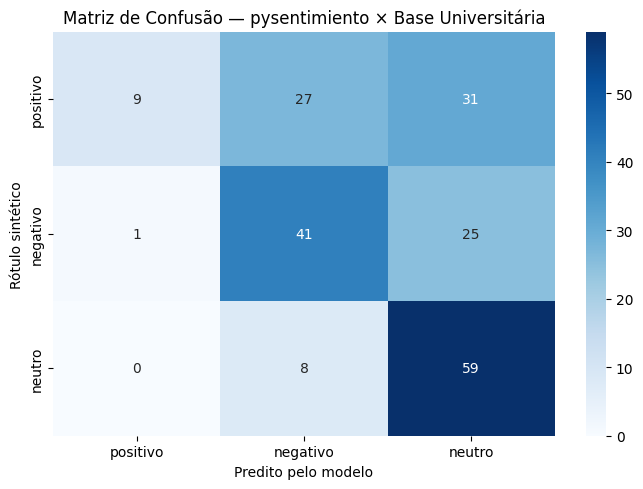


--- Acurácia por universidade ---
              acertos  total  acurácia
universidade                          
INSPER             18     25  0.720000
UFMG               13     21  0.619048
UFRJ               14     23  0.608696
MACKENZIE          12     20  0.600000
USP                10     17  0.588235
UNICAMP            13     23  0.565217
UFBA               12     23  0.521739
UNB                 9     18  0.500000
FGV                 5     18  0.277778
PUC_SP              3     13  0.230769

 ==== Padrão de divergências ====
divergencia
positivo→neutro      31
positivo→negativo    27
negativo→neutro      25
neutro→negativo       8
negativo→positivo     1


In [6]:
amostra = pd.concat([
    df_posts[df_posts["sentimento"] == "positivo"].sample(min(67, (df_posts["sentimento"] == "positivo").sum()), random_state=42),
    df_posts[df_posts["sentimento"] == "negativo"].sample(min(67, (df_posts["sentimento"] == "negativo").sum()), random_state=42),
    df_posts[df_posts["sentimento"] == "neutro"].sample(min(67,   (df_posts["sentimento"] == "neutro").sum()),   random_state=42),
]).reset_index(drop=True)

print(f"Amostra: {len(amostra)} posts")
print(amostra["sentimento"].value_counts().to_string())

LABEL_MAP_MODELO = {"POS": "positivo", "NEG": "negativo", "NEU": "neutro"}

print(f"\n ==== Rodando pysentimiento... ====")
inicio = time.time()
y_pred = [LABEL_MAP_MODELO.get(analyzer_sent.predict(t).output, "neutro") for t in amostra["conteudo"].tolist()]
tempo  = time.time() - inicio
y_true = amostra["sentimento"].tolist()

print(f"\n{'='*55}")
print("==== RESULTADOS FINAIS — pysentimiento × Base Universitária ====")
print(f"{'='*55}")
print(f"==== Tempo: {tempo:.1f}s  |  {tempo/len(amostra)*1000:.1f} ms/texto\n ====")
print(classification_report(y_true, y_pred, digits=3))
print(f"F1-Macro: {f1_score(y_true, y_pred, average='macro'):.4f}")

# Matriz de confusão
labels = ["positivo", "negativo", "neutro"]
cm     = confusion_matrix(y_true, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Predito pelo modelo")
ax.set_ylabel("Rótulo sintético")
ax.set_title("Matriz de Confusão — pysentimiento × Base Universitária")
plt.tight_layout()
plt.show()

# Acurácia por universidade
amostra = amostra.copy()
amostra["pred"]   = y_pred
amostra["acerto"] = amostra["sentimento"] == amostra["pred"]
print("\n--- Acurácia por universidade ---")
print(
    amostra.groupby("universidade")["acerto"]
    .agg(["sum","count","mean"])
    .rename(columns={"sum":"acertos","count":"total","mean":"acurácia"})
    .sort_values("acurácia", ascending=False)
    .to_string()
)

# Padrão de divergências
print("\n ==== Padrão de divergências ====")
amostra["divergencia"] = amostra["sentimento"] + "→" + amostra["pred"]
print(amostra[amostra["acerto"] == False]
    .groupby("divergencia")["id"].count()
    .sort_values(ascending=False)
    .rename("ocorrências")
    .to_string()
)

#### 10. Resultado da testagem – Caminho para o Fine Tuning
O experimento com a base sintética universitária (v4, 750 posts, 10 temas políticos atuais, 10 universidades brasileiras) revelou queda expressiva de desempenho do pysentimiento em relação ao benchmark no TweetSentBR: **F1-Macro de 0.503** contra **0.890 em zero-shot**. A análise das divergências aponta viés do modelo para a classe Neutro em textos de debate político argumentativo, linguagem estruturalmente diferente dos tweets casuais em que o modelo foi treinado. Esse resultado fundamenta empiricamente a necessidade de fine-tuning no domínio político-acadêmico, previsto para a Sprint 4.

In [13]:
n_amostras = min(1000, len(df_posts))

sample = (
    df_posts[["conteudo", "sentimento", "tema", "universidade", "perfil"]]
    .sample(n_amostras, random_state=42)
)

os.makedirs("dados-projeto/base-sintetica", exist_ok=True)
sample.to_csv("dados-projeto/base-sintetica/amostra_posts.csv", index=False, encoding="utf-8-sig")

print(f"✅ sample_posts.csv exportado: {n_amostras} linhas")
print(sample["sentimento"].value_counts().to_string())

✅ sample_posts.csv exportado: 725 linhas
sentimento
neutro      261
negativo    244
positivo    220
